<a href="https://colab.research.google.com/github/Koks-creator/Real-Time-People-Counting-and-Occupancy-Prediction-System/blob/main/AreaOccupancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)
print(f'TF {tf.__version__}')

TF 2.19.0


In [ ]:
CONFIG = {
    'seq_len':       30,
    'horizons':      [30, 60],
    'zone_capacity': 36,
    'epochs':        50,
    'batch_size':    64,
    'patience':      15,
}

count: min=0 max=36 mean=12.5 std=8.14
step distribution:
  -3: 0.5%  (real: 0.4%)
  -2: 1.0%  (real: 0.6%)
  -1: 12.4%  (real: 8.7%)
  +0: 72.9%  (real: 75.4%)
  +1: 10.9%  (real: 11.9%)
  +2: 2.0%  (real: 2.5%)
  +3: 0.3%  (real: 0.2%)


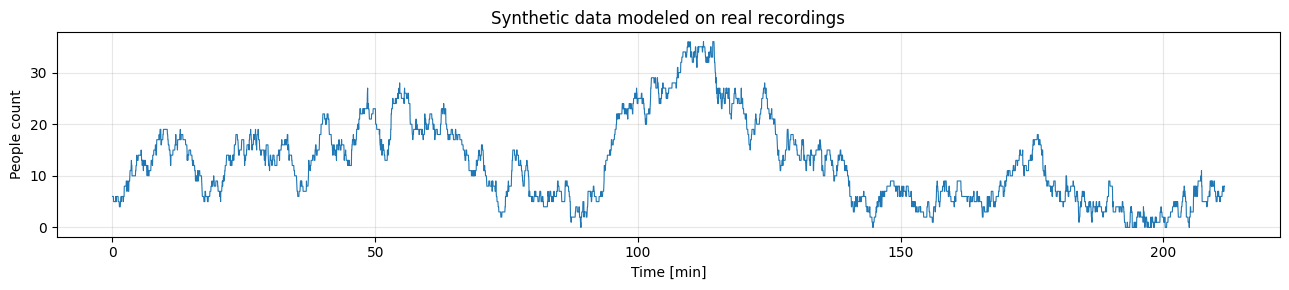

In [ ]:
def generate_from_real(n_hours=10, seed=0):
    """
    Generates synthetic people count data that mimics real YOLO detections.
    Based on statistical analysis of 6 real recording sessions:
      - sampling interval: ~2.54s (YOLOv11 processing time + 1s)
      - steps distribution: 75% no change, 12% +1, 9% -1, rare ±2/3
      - count range: 0–36, mean ~7, right-skewed distribution
    """
    rng = np.random.RandomState(seed)
    interval = 2.54                              # seconds per sample (matches real YOLO fps)
    steps = int(n_hours * 3600 / interval)       # total number of samples

    # step probabilities derived from real data diff analysis
    # slightly more -1 than +1 to prevent drift toward max capacity
    step_values = [-3, -2, -1,  0,  1,  2,  3]
    step_probs  = np.array([0.004, 0.010, 0.130, 0.720, 0.110, 0.020, 0.004])
    step_probs  /= step_probs.sum()              # normalize to sum = 1.0

    counts = np.zeros(steps)
    counts[0] = rng.randint(1, 10)              # start with low count (zone not yet active)

    # session = period with stable target occupancy level (simulates different scenes/times of day)
    session_len    = int(rng.uniform(200, 600))
    # exponential distribution: most sessions have low occupancy, rare busy periods
    # scale=3.0 gives mean ~3, matching real data mean of 7.1/36 ≈ 0.197 normalized
    session_target = np.clip(rng.exponential(scale=3.0), 0, 30)

    for i in range(1, steps):
        # periodically shift to a new occupancy level (new scene, rush hour, etc.)
        if i % session_len == 0:
            session_len    = int(rng.uniform(200, 600))
            session_target = np.clip(rng.exponential(scale=3.0), 0, 30)

        c    = counts[i-1]
        # mean reversion: gently pull count toward session target
        # strength 0.02 = slow drift, prevents random walk from diverging
        pull = (session_target - c) * 0.02
        step = rng.choice(step_values, p=step_probs) + pull
        counts[i] = np.clip(round(c + step), 0, 36)

    return pd.DataFrame({'timestamp': np.arange(steps) * interval,
                         'count': counts.astype(int)})


# ── Validation ──────────────────────────────────────────────────────────────
df = generate_from_real(n_hours=10)
diffs = np.diff(df['count'].values)
unique, freq = np.unique(diffs, return_counts=True)
total = len(diffs)

# summary stats — verify count range matches real data (0–36, mean ~7, std ~8)
print(f'count: min={df["count"].min()} max={df["count"].max()} mean={df["count"].mean():.1f} std={df["count"].std():.2f}')

# step distribution — compare synthetic vs real (shown in parentheses)
# goal: synthetic percentages should be close to real values
# if +1 >> -1 the generator will drift upward and saturate at max capacity
print('step distribution:')
for u, f_ in zip(unique, freq):
    if abs(f_/total) > 0.001:
        print(f'  {u:+d}: {f_/total*100:.1f}%  (real: {dict(zip([-3, -2, -1, 0, 1, 2, 3, 4], [0.4, 0.6, 8.7, 75.4, 11.9, 2.5, 0.2, 0.1])).get(u, "??")}%)')

# plot first 5000 samples (~3.5 hours) to visually check:
#   - no flat lines saturating at 0 or 36
#   - visible session shifts (step changes in baseline)
#   - realistic noise (not too smooth, not too chaotic)
plt.figure(figsize=(13, 3))
plt.plot(df['timestamp'][:5000] / 60, df['count'][:5000], linewidth=0.8)
plt.title('Synthetic data modeled on real recordings')
plt.xlabel('Time [min]'); plt.ylabel('People count')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
def build_dataset(df, cfg):
    seq_len  = cfg['seq_len']
    cap      = cfg['zone_capacity']
    counts   = df['count'].values
    times    = df['timestamp'].values
    X_seq, X_meta, Y, H = [], [], [], []

    for i in range(seq_len, len(df) - max(cfg['horizons'])):
        wt = times[i - seq_len : i]
        wc = counts[i - seq_len : i]
        duration = float(wt[-1] - wt[0])
        if duration < 1:
            continue

        seq = np.stack([
            (wt - wt[0]) / duration,   # czas relatywny [0..1]
            wc / cap                    # count znormalizowany
        ], axis=1).astype(np.float32)

        for horizon in cfg['horizons']:
            steps_ahead = int(horizon / 2.5)
            ti = i + horizon
            if ti >= len(counts):
                continue

            """
            Three numbers normalised to the same range `[0, 1]`:

            duration_s / 600   →  ‘I observed for X% of 10 minutes’
            horizon_s  / 600   →  ‘I want a prediction for X% of the next 10 minutes’
            capacity   / 200   →  ‘the zone accommodates X% of 200 people’
            """
            meta = np.array([duration / 600, horizon / 600, cap / 200], dtype=np.float32)
            X_seq.append(seq)
            X_meta.append(meta)
            Y.append(counts[ti] / cap)
            H.append(horizon)

    return np.array(X_seq), np.array(X_meta), np.array(Y, dtype=np.float32), np.array(H)


X_seq, X_meta, Y, H = build_dataset(df, CONFIG)

idx = np.arange(len(Y))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)

print(f'Train: {len(idx_tr):,}  |  Test: {len(idx_te):,}')
print(f'X_seq shape: {X_seq.shape}')

Train: 22,532  |  Test: 5,634
X_seq shape: (28166, 30, 2)


**`X_seq`** — shape `(N, seq_len, 2)` — input sequences. Each sample is a sliding window of 30 measurements, where each timestep has 2 features: `[relative_time_normalized, count_normalized]`. This is what the model "sees" as recent history.

**`X_meta`** — shape `(N, 3)` — scalar context per sample: `[duration_s / 600, horizon_s / 600, capacity / 200]`. Tells the model how long the observation window was, how far ahead to predict, and the zone's max capacity.

**`Y`** — shape `(N,)` — targets, normalized to `[0, 1]`. Each value is the actual people count at `t + horizon`, divided by capacity. Multiply by capacity to get the real number.

**`H`** — shape `(N,)` — horizon label per sample in seconds (e.g. `30, 60, 180, 300`). Not fed to the model — used only for evaluation to compute metrics separately per prediction horizon.

Samples: 28,166
Y std:  0.2265
Y mean: 0.3474
Y min:  0.0000
Y max:  1.0000


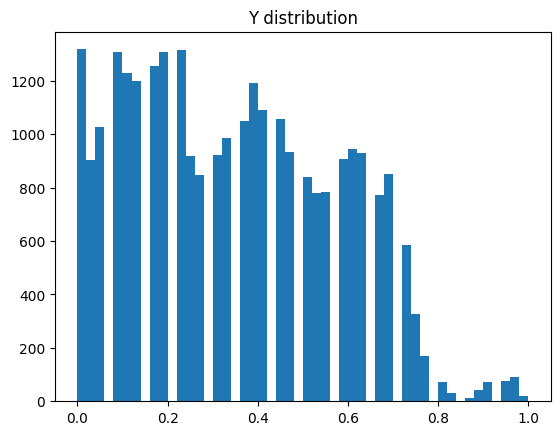

In [ ]:
X_seq, X_meta, Y, H = build_dataset(df, CONFIG)

print(f'Samples: {len(Y):,}')
print(f'Y std:  {Y.std():.4f}')
print(f'Y mean: {Y.mean():.4f}')
print(f'Y min:  {Y.min():.4f}')
print(f'Y max:  {Y.max():.4f}')

plt.hist(Y, bins=50)
plt.title('Y distribution')
plt.show()

### Why `Concatenate`?

The model has two inputs that ‘operate independently’ — the sequence goes through the LSTM, and the metadata through the Dense layer. To combine these two streams into a single vector before the final prediction, they need to be concatenated:

```
sequence → LSTM → vector of 32 numbers  ┐
                                      ├─ Concatenate → 48-element vector → Dense → result
metadata  → Dense → 16-element vector ┘
```

Without this, the model would not know how to link “motion dynamics” with “temporal context”.

---

### `x`, `m`, `z`
- `x` — output of the sequence branch (LSTM)
- `m` — output of the metadata branch (meta)
- `z` — combined together, goes to the final Dense layers

They could be called `lstm_out`, `meta_out`, `combined`.

---

### MSE and MAE

**MSE (Mean Squared Error)** — the loss function, i.e. what the model learns to minimise:
```
MSE = average of (true - predicted)²
```
The squaring means that large errors are **very heavily penalised** — the model prefers to make many small errors rather than one large one.

**MAE (Mean Absolute Error)** — merely a metric for monitoring, does not affect learning:
```
MAE = mean of |actual - predicted|
```
Easier to interpret — with `capacity=36` and `MAE=0.08`, the error is `0.08 × 36 ≈ 3 people`.

---

### Sigmoid at the output

```python
out = keras.layers.Dense(1, activation=“sigmoid”)(z)
```

The sigmoid function returns values in the range `[0, 1]` — ideally, as the targets are also normalised to `[0, 1]`. During inference, you multiply by `capacity` to obtain the number of people.

In [ ]:
def build_model(seq_len):
    seq_in  = keras.Input(shape=(seq_len, 2), name='sequence')
    meta_in = keras.Input(shape=(3,),         name='metadata')

    x = keras.layers.LSTM(64, return_sequences=True)(seq_in)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.LSTM(32)(x)

    m = keras.layers.Dense(16, activation='relu')(meta_in)

    z = keras.layers.Concatenate()([x, m])
    z = keras.layers.Dense(64, activation='relu')(z)
    z = keras.layers.Dense(32, activation='relu')(z)
    out = keras.layers.Dense(1, activation='sigmoid')(z)

    model = keras.Model(inputs={'sequence': seq_in, 'metadata': meta_in}, outputs=out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


model = build_model(CONFIG['seq_len'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 30, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 64)    │     17,152 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      3,136 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,881 (136.25 KB)

 Trainable params: 34,881 (136.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
idx = np.arange(len(Y))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)

In [ ]:
model = build_model(CONFIG['seq_len'])

In [ ]:
history = model.fit(
    {'sequence': X_seq[idx_tr], 'metadata': X_meta[idx_tr]}, Y[idx_tr],
    validation_split=0.15,
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=1),
    ],
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 0.0183 - mae: 0.1048 - val_loss: 0.0130 - val_mae: 0.0908 - learning_rate: 0.0010
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0135 - mae: 0.0915 - val_loss: 0.0127 - val_mae: 0.0891 - learning_rate: 0.0010
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0130 - mae: 0.0901 - val_loss: 0.0125 - val_mae: 0.0882 - learning_rate: 0.0010
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 0.0128 - mae: 0.0893 - val_loss: 0.0123 - val_mae: 0.0876 - learning_rate: 0.0010
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0127 - mae: 0.0888 - val_loss: 0.0122 - val_mae: 0.0869 - learning_rate: 0.0010
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - loss: 0.0126 - mae: 0.0885 - val_loss: 0.0121 - val_mae: 0.0867 - learning_rate: 0.0010
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.0125 - mae: 0.0881 - val_loss: 0.0121 - val_mae: 0.0862 - learning_rate:

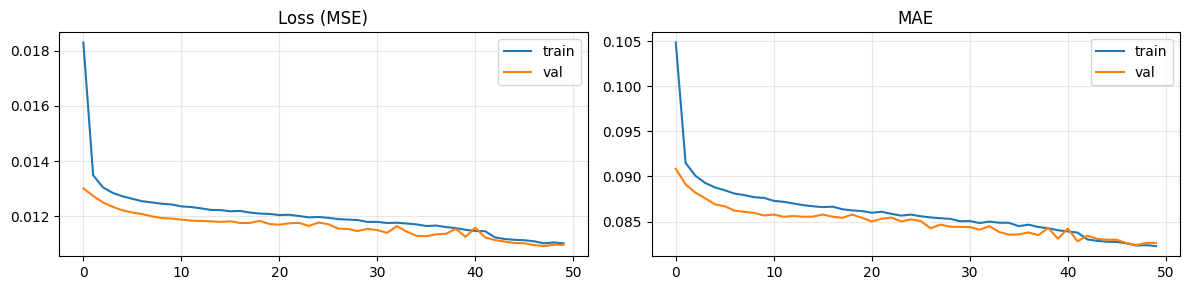

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, key, title in zip(axes, ['loss', 'mae'], ['Loss (MSE)', 'MAE']):
    ax.plot(history.history[key], label='train')
    ax.plot(history.history[f'val_{key}'], label='val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
model.save('zone_model.h5')

MAE:  2.94 osób
R²:   0.7943

  Horyzont |      MAE |       R² |       N
------------------------------------------
       30s |    2.53  |   0.8507 |   2,826
       60s |    3.35  |   0.7349 |   2,808


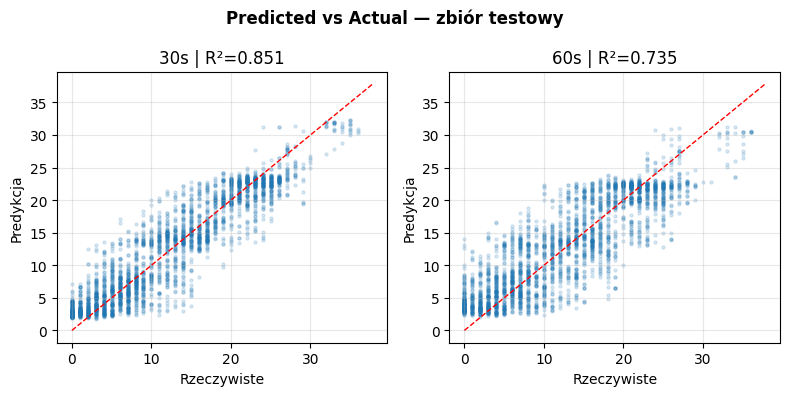

In [ ]:
cap = CONFIG['zone_capacity']

# Run model on test set and denormalize: model outputs [0,1], multiply by capacity to get people count
y_pred = model.predict(
    {'sequence': X_seq[idx_te], 'metadata': X_meta[idx_te]}, verbose=0
).flatten() * cap
y_true = Y[idx_te] * cap  # denormalize ground truth the same way
h_te   = H[idx_te]        # horizon labels for the test set (used to split metrics per horizon)

# ── Overall metrics ──────────────────────────────────────────────────────────
# MAE: average error in number of people — easy to interpret ("off by X people on average")
# R²:  how much variance the model explains; 1.0 = perfect, 0.0 = predicting the mean
print(f'MAE:  {mean_absolute_error(y_true, y_pred):.2f} people')
print(f'R²:   {r2_score(y_true, y_pred):.4f}')
print()

# ── Metrics per prediction horizon ───────────────────────────────────────────
# Expected: MAE increases and R² drops as horizon grows —
# short-term predictions (30s) should be more accurate than long-term (300s)
print(f'{"Horizon":>10} | {"MAE":>8} | {"R²":>8} | {"N":>7}')
print('-' * 42)
for h in sorted(CONFIG['horizons']):
    m   = h_te == h                              # boolean mask: select only samples for this horizon
    mae = mean_absolute_error(y_true[m], y_pred[m])
    r2  = r2_score(y_true[m], y_pred[m])
    print(f'{str(h)+"s":>10} | {mae:>7.2f}  | {r2:>8.4f} | {m.sum():>7,}')

# ── Predicted vs Actual scatter plots ────────────────────────────────────────
# One plot per horizon. Points should cluster around the red diagonal (y=x line).
# Spread around the diagonal = model error.
# A horizontal band of points = model predicts a constant (bad sign — learned the mean).
horizons = sorted(CONFIG['horizons'])
fig, axes = plt.subplots(1, len(horizons), figsize=(4 * len(horizons), 4))
for ax, h in zip(axes, horizons):
    m = h_te == h
    ax.scatter(y_true[m], y_pred[m], alpha=0.15, s=5)
    lim = max(y_true[m].max(), y_pred[m].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1)    # perfect prediction line
    ax.set_title(f'{h}s | R²={r2_score(y_true[m], y_pred[m]):.3f}')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.grid(alpha=0.3)
plt.suptitle('Predicted vs Actual — test set', fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
def predict_zone(model, recent_counts: list, duration_s: float, horizon_s: int, capacity: int) -> dict:
    """
    recent_counts  — the last N measurements from YOLOv11 (deque containing 30 values)
    duration_s     — how many seconds it took to collect the measurements
    horizon_s      — how many seconds into the future we want the prediction
    capacity       — maximum capacity of the zone
    """
    n   = len(recent_counts)
    seq = np.array(
        [[i / (n - 1), c / capacity] for i, c in enumerate(recent_counts)],
        dtype=np.float32
    )[np.newaxis, ...]  # (1, n, 2)

    meta = np.array([[duration_s / 600, horizon_s / 600, capacity / 200]], dtype=np.float32)

    pred = float(model.predict({'sequence': seq, 'metadata': meta}, verbose=0)[0, 0]) * capacity
    return {
        'predicted_count': round(pred),
        'occupancy_pct':   round(pred / capacity * 100, 1),
        'horizon_s':       horizon_s,
    }

In [ ]:
model = keras.models.load_model('zone_model.h5', compile=False)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print('Model załadowany')
model.summary()

Model załadowany


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 30, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 30, 64)    │     17,152 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │         64 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      3,136 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,881 (136.25 KB)

 Trainable params: 34,881 (136.25 KB)

 Non-trainable params: 0 (0.00 B)

### `seq` — input sequence

```python
seq = np.array(
    [[i / (n - 1), c / capacity] for i, c in enumerate(recent_counts)],
    dtype=np.float32
)[np.newaxis, ...]
```

For each sample, it creates a pair `[relative_time, normalised_count]`:

```
i=0,  c=12  →  [0.0,   0.33]   # first sample, 12/36
i=1,  c=13  →  [0.034, 0.36]
...
i=29, c=20  →  [1.0,   0.55]   # last sample
```

`i / (n-1)` normalises the time to `[0, 1]` — the model does not know how many seconds have elapsed, only ‘where in the window’ a given sample is. That is why `duration_s` is provided separately in the metadata.

`[np.newaxis, ...]` adds the batch dimension — the model expects `(batch, seq_len, 2)`, and we have `(seq_len, 2)`, so it becomes `(1, 30, 2)`.

---

### `meta` — metadata

```python
meta = np.array([[duration_s / 600, horizon_s / 600, capacity / 200]], dtype=np.float32)
```

Three numbers normalised to a similar range `[0, 1]`:

```
duration_s / 600   →  ‘I observed for X% of 10 minutes’
horizon_s  / 600   →  ‘I want a prediction for X% of the next 10 minutes’
capacity   / 200   →  ‘the zone accommodates X% of 200 people’
```

`600` and `200` are arbitrary maximums — it is important that they are consistent with the training.

---

### Output and denormalisation

```python
pred = float(self.model.predict(...)[0, 0]) * capacity
```

The model returns `(1, 1)` — one batch, one value. `[0, 0]` extracts the scalar. Multiplying by `capacity` reverses the normalisation:

```
model output: 0.61
× capacity 36 = 21.96
round() → 22 people
```

In [ ]:
def predict_zone(model, recent_counts: list, duration_s: float, horizon_s: int, capacity: int) -> dict:
    n   = len(recent_counts)
    seq = np.array(
        [[i / (n - 1), c / capacity] for i, c in enumerate(recent_counts)],
        dtype=np.float32
    )[np.newaxis, ...]

    meta = np.array([[duration_s / 600, horizon_s / 600, capacity / 200]], dtype=np.float32)

    pred = float(model.predict({'sequence': seq, 'metadata': meta}, verbose=0)[0, 0]) * capacity
    return {
        'predicted_count': round(pred),
        'occupancy_pct':   round(pred / capacity * 100, 1),
        'horizon_s':       horizon_s,
    }

In [ ]:
recent_counts = [3, 3, 4, 4, 5, 5, 6, 7, 7, 8,
                 9, 10, 10, 11, 12, 12, 13, 13, 14, 15,
                 15, 16, 16, 17, 17, 18, 18, 19, 19, 20]

CAPACITY   = 36
DURATION_S = len(recent_counts) * 2.54  # 30 samples × 2.54s ≈ 76s
HORIZONS   = [30, 60]

print(f'input: min={min(recent_counts)} max={max(recent_counts)} last={recent_counts[-1]}')
print()

for h in HORIZONS:
    result = predict_zone(model, recent_counts, duration_s=DURATION_S, horizon_s=h, capacity=CAPACITY)
    print(f'In {h}s → {result["predicted_count"]} ppl ({result["occupancy_pct"]}% capacity)')

Dane wejściowe: min=3 max=20 ostatnia=20

Za 30s → 22 osób (59.9% pojemności)
Za 60s → 22 osób (61.4% pojemności)


In [ ]:
# case 2 — upward trend
counts_down = [20, 20, 19, 19, 18, 17, 17, 16, 15, 15,
               14, 13, 13, 12, 11, 11, 10, 10, 9, 8,
               8, 7, 7, 6, 5, 5, 4, 4, 3, 3]

# case 3 — downward stable
counts_flat = [15, 15, 16, 15, 14, 15, 16, 15, 15, 14,
               15, 16, 15, 15, 14, 15, 16, 15, 15, 14,
               15, 16, 15, 15, 14, 15, 16, 15, 15, 14]

for label, counts in [('Upward trendy', recent_counts),
                      ('Downward trend',  counts_down),
                      ('Stable',        counts_flat)]:
    print(f'{label} (last={counts[-1]}):')
    for h in HORIZONS:
        r = predict_zone(model, counts, duration_s=DURATION_S, horizon_s=h, capacity=CAPACITY)
        print(f'  Za {h}s → {r["predicted_count"]} ppl')
    print()

Trend wzrostowy (ostatnia=20):
  Za 30s → 22 osób
  Za 60s → 22 osób

Trend spadkowy (ostatnia=3):
  Za 30s → 6 osób
  Za 60s → 7 osób

Stabilny (ostatnia=14):
  Za 30s → 13 osób
  Za 60s → 13 osób

